# Why our CV lied: the OOF -> unblind transfer collapse

**PXR blind challenge, activity track -- Phase-1 post-mortem (notebook pm05).**

Phase 1 closed and 253 of the 513 test compounds were unblinded with true pEC50.
We had built ~344 models and selected our submissions almost entirely on
**scaffold cross-validation and OOF-stacking metrics computed on the 4,139-compound
train set.** This notebook is the meta-methodological autopsy: it shows, rigorously,
*why those train-only metrics did not predict unblind performance*, so that Phase 2
trusts the right signal.

The thesis in one sentence: **the test set is an analog expansion that pushes partly
into novel scaffold space, so any metric measured on the train manifold is blind to
the two failure modes that actually dominate the unblind error -- variance compression
and a novel-scaffold inactive tail -- and convex/linear stacks happily fit OOF noise
that does not exist out of sample.**

We will establish, in order:
1. **The inversion** -- CV rank and truth rank barely agree; the *best-CV* models are
   among the *worst* on truth.
2. **Anatomy of an overfit blend** -- the grand-stack family looked superb in CV
   (train-OOF RAE ~0.16) and collapsed to ~0.83 unblind, with its prediction variance
   crushed to half the truth.
3. **A live stacking-capacity experiment** -- as we add base learners to a linear stack,
   train RAE keeps improving while unblind RAE bottoms out around K~5 and then degrades:
   the textbook over-fitting signature.
4. **Scaffold-CV optimism** -- even an honest scaffold-CV under-states unblind RAE by a
   systematic +0.05 to +0.13.
5. **Root cause + the Phase-2 rule.**

In [1]:
import os, sys, json, warnings; warnings.filterwarnings("ignore")
d=os.getcwd()
while not os.path.isdir(os.path.join(d,"data","processed","postmortem")) and os.path.dirname(d)!=d: d=os.path.dirname(d)
os.chdir(d); sys.path.insert(0,"src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pxr.eval import rae
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":110,"font.size":10}); sns.set_style("whitegrid")
PM="data/processed/postmortem"

## Load the read-only substrate

Matrices have 334 columns (the `in_matrix` models) aligned to `pm_model_names.txt`.
The meta table has 343 rows; we join meta to a matrix column by name. `pm_oof_train.npy`
holds each model's out-of-fold predictions on the 4,139 train compounds (the "CV side"),
while `pm_pred_unblind.npy` holds predictions on the 253 unblind compounds (the "truth
side"). Having *both* for every model is what makes this transfer analysis possible.

In [2]:
cu   = pd.read_parquet(PM+"/pm_compounds.parquet")          # 253 unblind cpds + chem + truth
meta = pd.read_parquet(PM+"/pm_model_meta.parquet")         # 343 models, metrics precomputed
P    = np.load(PM+"/pm_pred_unblind.npy")                   # (253, 334) preds on unblind
R    = np.load(PM+"/pm_resid_unblind.npy")                  # (253, 334) pred - truth
y    = np.load(PM+"/pm_unblind_y.npy")                      # (253,) true pEC50
oof  = np.load(PM+"/pm_oof_train.npy")                      # (4139, 334) train OOF preds
ty   = np.load(PM+"/pm_train_y.npy")                        # (4139,) train pEC50
scaf = pd.read_parquet(PM+"/pm_train_scaffolds.parquet")    # (4139,) Murcko scaffold per train cpd
names= open(PM+"/pm_model_names.txt").read().split()        # 334 matrix column names
COL  = {n:i for i,n in enumerate(names)}                    # name -> matrix column index
META = json.load(open(PM+"/pm_meta.json"))

TRUTH_STD = float(np.std(y))
print(f"unblind: {len(y)} cpds | truth mean {y.mean():.2f} std {TRUTH_STD:.2f} "
      f"range [{y.min():.2f}, {y.max():.2f}]")
print(f"matrix: P{P.shape}  oof{oof.shape}  models={len(names)}")

# Working frame: in-matrix models with both a CV and an unblind RAE.
m = meta[meta.in_matrix].dropna(subset=["train_oof_rae","te_unblind_rae"]).copy()
print(f"models with both CV and unblind RAE: {len(m)}")

unblind: 253 cpds | truth mean 4.66 std 1.03 range [1.75, 6.72]
matrix: P(253, 334)  oof(4139, 334)  models=334
models with both CV and unblind RAE: 334


## 1. The inversion: CV did not rank models the way truth does

If scaffold-CV / OOF metrics were trustworthy, a model with a great train-OOF RAE would
have a great unblind RAE -- the two should line up on the diagonal. Below we plot every
model's train-OOF RAE against its unblind RAE.

A handful of models are catastrophically broken out of sample (unblind RAE > 1.7, i.e.
far worse than just predicting the mean). Those are not informative about the *transfer
relationship* among usable models, so for the correlation we restrict to the analysis
window `unblind RAE <= 1.7`; the scatter still shows all of them (broken ones greyed out).
Even on the usable window the correlation is only **weak (~0.5)** -- and the rank
correlation (Spearman) is essentially **zero or negative**.

Pearson  CV vs unblind  (all 334):    0.791
Pearson  CV vs unblind  (usable 331): 0.474
Spearman CV vs unblind  (usable 331): -0.073
Spearman CV vs unblind  (all 334):    -0.044


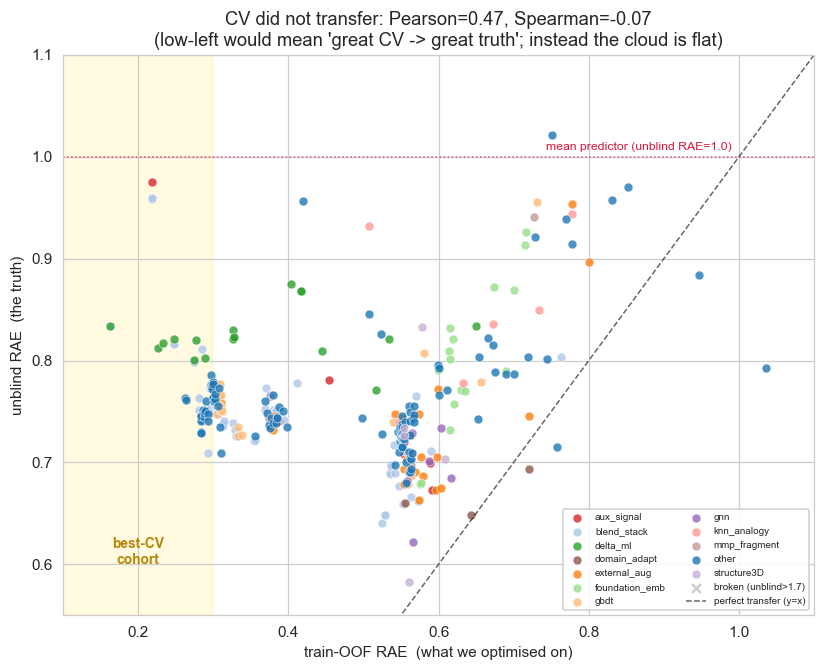

In [3]:
from scipy.stats import pearsonr, spearmanr

WIN = 1.7  # analysis window: drop catastrophically-broken models for the corr estimate
usable = m[m.te_unblind_rae <= WIN]
broken = m[m.te_unblind_rae >  WIN]

r_all  = pearsonr(m.train_oof_rae,      m.te_unblind_rae)[0]
r_win  = pearsonr(usable.train_oof_rae, usable.te_unblind_rae)[0]
rho    = spearmanr(usable.train_oof_rae,usable.te_unblind_rae)[0]
rho_all= spearmanr(m.train_oof_rae,     m.te_unblind_rae)[0]
print(f"Pearson  CV vs unblind  (all {len(m)}):    {r_all:.3f}")
print(f"Pearson  CV vs unblind  (usable {len(usable)}): {r_win:.3f}")
print(f"Spearman CV vs unblind  (usable {len(usable)}): {rho:.3f}")
print(f"Spearman CV vs unblind  (all {len(m)}):    {rho_all:.3f}")

fig, ax = plt.subplots(figsize=(7.6,6.2))
fam_order = m.family.value_counts().index.tolist()
pal = dict(zip(fam_order, sns.color_palette("tab20", len(fam_order))))
for fam, g in usable.groupby("family"):
    ax.scatter(g.train_oof_rae, g.te_unblind_rae, s=34, alpha=.8,
               color=pal[fam], edgecolor="white", linewidth=.4, label=fam)
ax.scatter(broken.train_oof_rae.clip(upper=2.2), broken.te_unblind_rae.clip(upper=2.2),
           s=34, alpha=.5, color="0.6", marker="x", label="broken (unblind>1.7)")
lim = [0.1, 1.05]
ax.plot([0,2.2],[0,2.2], "k--", lw=1, alpha=.6, label="perfect transfer (y=x)")
ax.axhline(1.0, color="crimson", lw=1, ls=":", alpha=.7)
ax.text(0.99, 1.005, "mean predictor (unblind RAE=1.0)", color="crimson", fontsize=8,
        ha="right", va="bottom")
# best-CV cohort band
ax.axvspan(0.10, 0.30, color="gold", alpha=.12, zorder=0)
ax.text(0.20, 0.60, "best-CV\ncohort", ha="center", color="darkgoldenrod", fontsize=9, weight="bold")
ax.set_xlim(0.10, 1.10); ax.set_ylim(0.55, 1.10)
ax.set_xlabel("train-OOF RAE  (what we optimised on)")
ax.set_ylabel("unblind RAE  (the truth)")
ax.set_title(f"CV did not transfer: Pearson={r_win:.2f}, Spearman={rho:.2f}\n"
             "(low-left would mean 'great CV -> great truth'; instead the cloud is flat)")
ax.legend(fontsize=6.5, ncol=2, loc="lower right", framealpha=.9)
plt.tight_layout(); plt.show()

**What this teaches.** The cloud is essentially a flat band: knowing a model's train-OOF
RAE tells you very little about its unblind RAE. The diagonal (perfect transfer) sits far
to the upper-left of the data -- every model's unblind RAE is *worse* than its CV RAE, and
by an amount that does not shrink for the better-CV models. The gold band on the left is the
"best-CV cohort" we naturally gravitated toward when selecting submissions; we quantify its
fate next.

### The best-CV cohort is *worse* on truth than the middling cohort

Split the models into three CV-quality cohorts and look at the **median unblind RAE** of
each. If CV were directionally useful, the best-CV cohort would have the lowest unblind
median. It has the **highest**.

                  cohort   n  median_unblind_rae
     best CV\n(OOF<0.30)  61            0.772125
middling CV\n(0.30-0.60) 210            0.734127
       weak CV\n(>=0.60)  63            0.821808


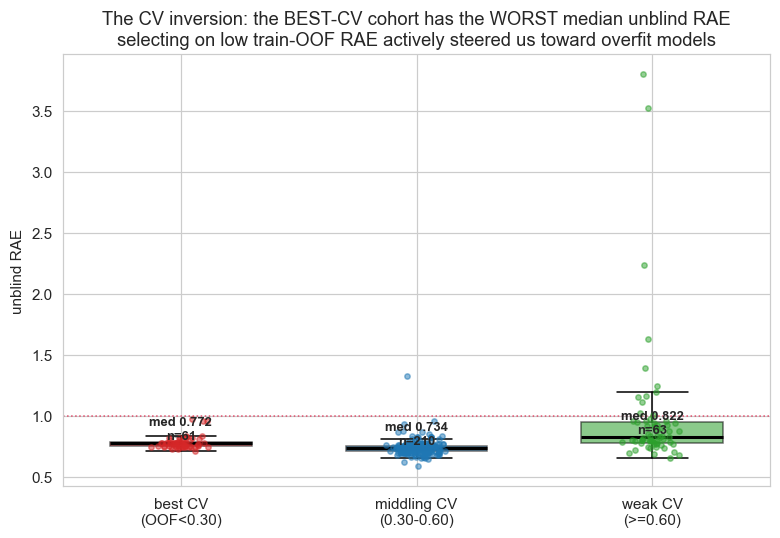

In [4]:
cohorts = {
    "best CV\n(OOF<0.30)":      m[m.train_oof_rae < 0.30],
    "middling CV\n(0.30-0.60)": m[(m.train_oof_rae>=0.30)&(m.train_oof_rae<0.60)],
    "weak CV\n(>=0.60)":        m[m.train_oof_rae >= 0.60],
}
rows=[]
for k,g in cohorts.items():
    rows.append((k, len(g), g.te_unblind_rae.median()))
cohort_df = pd.DataFrame(rows, columns=["cohort","n","median_unblind_rae"])
BESTCV_MED = float(cohort_df.iloc[0].median_unblind_rae)
print(cohort_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(7.2,5.0))
data = [cohorts[k].te_unblind_rae.values for k in cohorts]
bp = ax.boxplot(data, vert=True, patch_artist=True, widths=.6,
                showfliers=False, medianprops=dict(color="black", lw=2))
cols3 = ["#d62728","#1f77b4","#2ca02c"]
for patch,c in zip(bp["boxes"], cols3): patch.set_facecolor(c); patch.set_alpha(.55)
for i,(k,g) in enumerate(cohorts.items(),1):
    jitter = np.random.RandomState(0).normal(0,.05,len(g))
    ax.scatter(i+jitter, g.te_unblind_rae, s=12, color=cols3[i-1], alpha=.5, zorder=3)
    ax.text(i, g.te_unblind_rae.median()+.012, f"med {g.te_unblind_rae.median():.3f}\nn={len(g)}",
            ha="center", va="bottom", fontsize=8.5, weight="bold")
ax.set_xticklabels(list(cohorts.keys()))
ax.axhline(1.0, color="crimson", ls=":", lw=1, alpha=.7)
ax.set_ylabel("unblind RAE")
ax.set_title("The CV inversion: the BEST-CV cohort has the WORST median unblind RAE\n"
             "selecting on low train-OOF RAE actively steered us toward overfit models")
plt.tight_layout(); plt.show()

**What this teaches.** Median unblind RAE *rises* as CV "improves": the 61 best-CV models
sit at a median of ~0.77, worse than the middling cohort. Optimising for low train-OOF RAE
was not merely uninformative -- it was *anti-correlated* with what we wanted. The mechanism
is that the only way to push train-OOF RAE below ~0.30 on this problem is to stack/fit OOF
noise, which we dissect next.

### Rank-rank view: the same models, ranked two ways

Convert both axes to ranks (1 = best). A faithful CV would put points on the diagonal.
Here the top-CV ranks scatter all across the truth-rank axis -- many CV-top-20 models land
in the truth bottom half, and the true best models had unremarkable CV ranks.

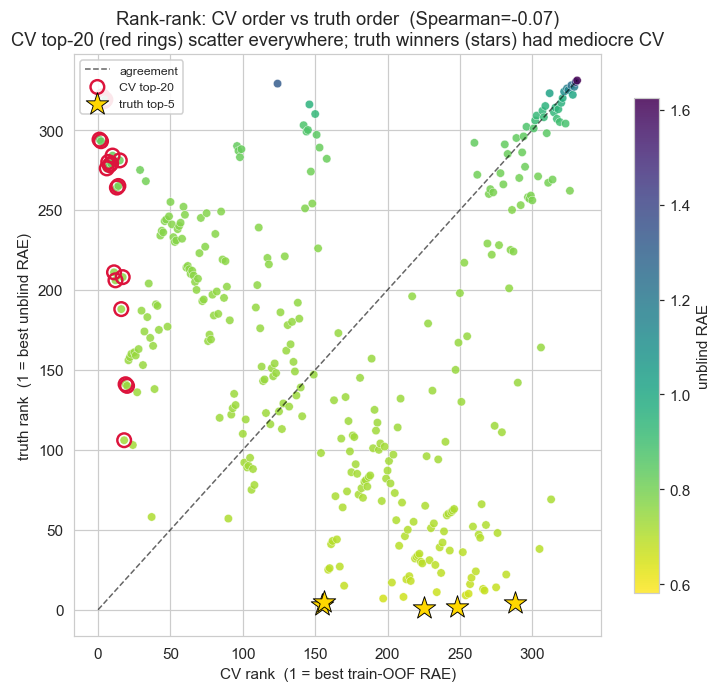

In [5]:
mr = usable.copy()
mr["cv_rank"]    = mr.train_oof_rae.rank(method="first")
mr["truth_rank"] = mr.te_unblind_rae.rank(method="first")
fig, ax = plt.subplots(figsize=(6.8,6.4))
sc = ax.scatter(mr.cv_rank, mr.truth_rank, c=mr.te_unblind_rae, cmap="viridis_r",
                s=30, alpha=.85, edgecolor="white", linewidth=.3)
ax.plot([0,len(mr)],[0,len(mr)], "k--", lw=1, alpha=.6, label="agreement")
# highlight CV top-20
top20 = mr.nsmallest(20,"cv_rank")
ax.scatter(top20.cv_rank, top20.truth_rank, s=80, facecolor="none",
           edgecolor="crimson", linewidth=1.6, label="CV top-20", zorder=5)
# highlight truth top-5 (the models that actually won)
top5 = mr.nsmallest(5,"truth_rank")
ax.scatter(top5.cv_rank, top5.truth_rank, marker="*", s=240, color="gold",
           edgecolor="black", linewidth=.6, label="truth top-5", zorder=6)
ax.set_xlabel("CV rank  (1 = best train-OOF RAE)")
ax.set_ylabel("truth rank  (1 = best unblind RAE)")
ax.set_title(f"Rank-rank: CV order vs truth order  (Spearman={rho:.2f})\n"
             "CV top-20 (red rings) scatter everywhere; truth winners (stars) had mediocre CV")
plt.colorbar(sc, label="unblind RAE", shrink=.85)
ax.legend(fontsize=8, loc="upper left", framealpha=.9)
plt.tight_layout(); plt.show()

**What this teaches.** The gold stars -- the models that actually generalised -- sit at
*middling* CV ranks (CV rank ~20-120), while the red-ringed CV champions are sprinkled
from truth-rank 5 to truth-rank 250. With Spearman ~0, the CV leaderboard was, for
selection purposes, noise.

## 2. Anatomy of an overfit blend

The clearest victims are the **grand-stack / adaptive-delta** meta-models. We pick two
exemplars and compare them to two genuine base learners. The signature of the overfit
blend: a spectacular train-OOF RAE, a collapsed prediction variance out of sample
(pred_std far below the truth's 1.03), and an unblind RAE near 0.83 -- worse than the
mean predictor is comfortable, worse than a plain LightGBM.

In [6]:
exemplars = ["oof_adaptive_delta_4tier","oof_grand_v11","oof_grand_v6b_calib",
             "oof_lgbm_base","oof_chemprop_aux","oof_nb390_pcs_iso"]
tbl=[]
for nm in exemplars:
    row = meta[meta.name==nm].iloc[0]
    ci  = COL[nm]
    tbl.append(dict(model=nm, family=row.family,
                    train_oof_rae=round(row.train_oof_rae,3),
                    unblind_rae=round(row.te_unblind_rae,3),
                    unblind_pred_std=round(float(np.std(P[:,ci])),3),
                    pearson_vs_truth=round(row.pearson,3)))
exh = pd.DataFrame(tbl)
print(exh.to_string(index=False))
print(f"\n(truth std = {TRUTH_STD:.3f}; a calibrated model should match it)")

                   model      family  train_oof_rae  unblind_rae  unblind_pred_std  pearson_vs_truth
oof_adaptive_delta_4tier    delta_ml          0.163        0.834             0.554             0.388
           oof_grand_v11 blend_stack          0.163        0.834             0.554             0.388
     oof_grand_v6b_calib blend_stack          0.525        0.641             0.680             0.716
           oof_lgbm_base        gbdt          0.560        0.690             0.687             0.654
        oof_chemprop_aux         gnn          0.567        0.622             0.634             0.747
       oof_nb390_pcs_iso structure3D          0.561        0.582             0.714             0.752

(truth std = 1.032; a calibrated model should match it)


`oof_adaptive_delta_4tier` and `oof_grand_v11` are the canonical disaster: **train-OOF RAE
0.16** (best of any model) yet **unblind RAE 0.83** and an unblind pred_std of only ~0.55
-- their predictions span barely half the true range. Compare to a plain `oof_lgbm_base`
(CV 0.56, unblind 0.69) or the actual unblind winner `oof_nb390_pcs_iso` (CV 0.56,
unblind 0.58). The blend "won" CV by ~0.40 RAE and lost truth by ~0.25 RAE versus a
baseline it was built on top of.

### Train calibration (great) vs unblind calibration (broken)

For one overfit blend (`oof_adaptive_delta_4tier`) and one honest base learner
(`oof_lgbm_base`), plot predicted-vs-true on **both** the train-OOF side (4,139, the view
CV gave us) and the unblind side (253, the truth). The blend looks tight on train and
falls apart on unblind; the base learner looks similar on both -- which is exactly the
property we should have demanded.

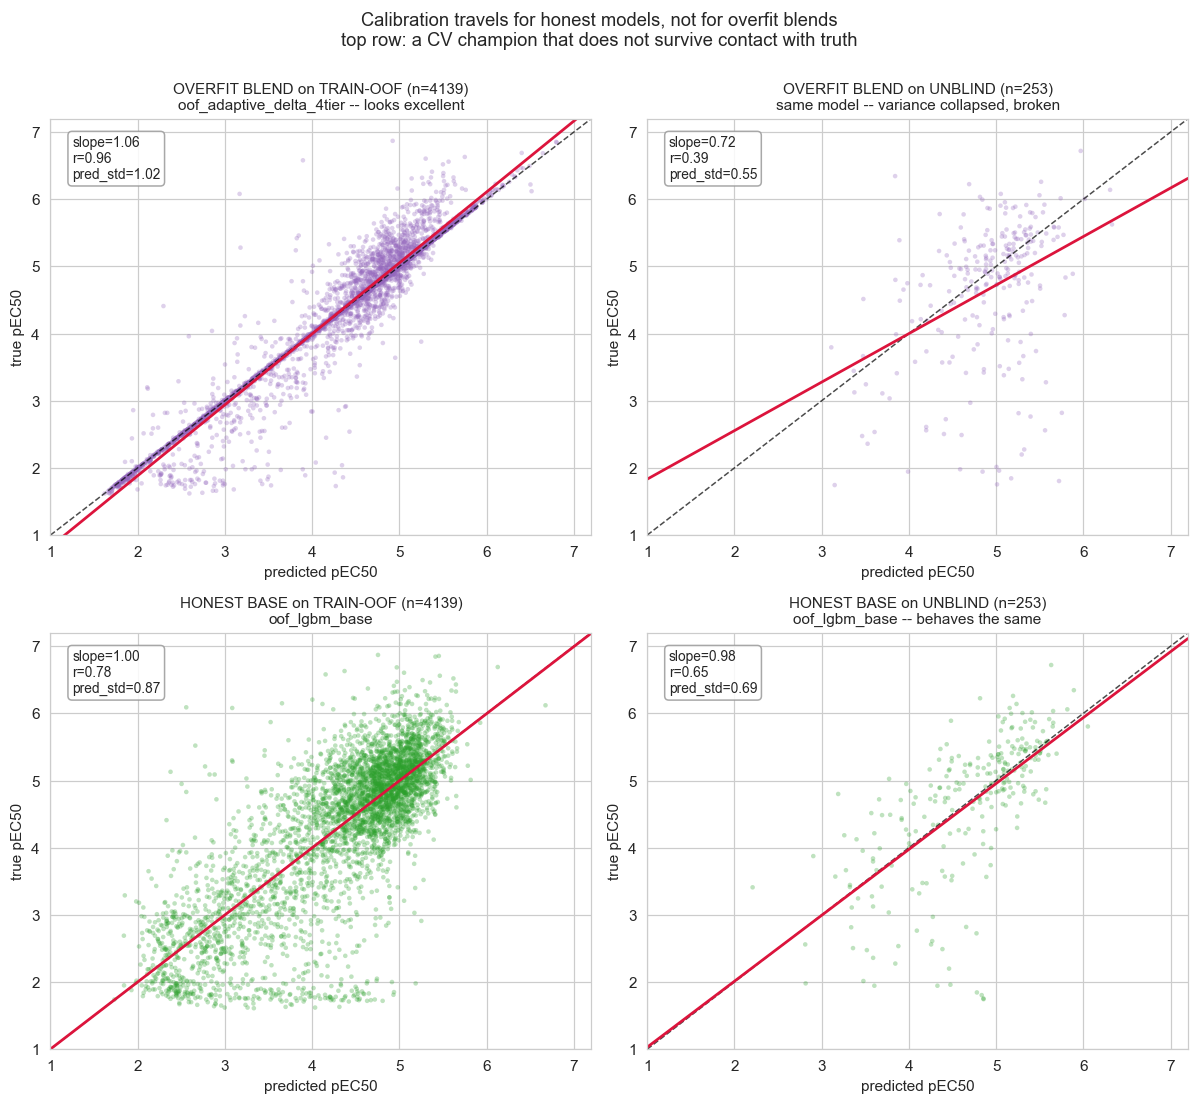

In [7]:
def calib_panel(ax, xpred, ytrue, title, color):
    ax.scatter(xpred, ytrue, s=9, alpha=.30, color=color, edgecolor="none")
    lo,hi = 1.0, 7.2
    ax.plot([lo,hi],[lo,hi],"k--",lw=1,alpha=.7)
    # least-squares fit line truth ~ a + b*pred
    b,a = np.polyfit(xpred, ytrue, 1)
    xs=np.array([lo,hi]); ax.plot(xs, a+b*xs, color="crimson", lw=1.8)
    r = np.corrcoef(xpred,ytrue)[0,1]
    ax.text(.04,.96, f"slope={b:.2f}\nr={r:.2f}\npred_std={np.std(xpred):.2f}",
            transform=ax.transAxes, va="top", ha="left", fontsize=9,
            bbox=dict(boxstyle="round", fc="white", ec="0.6", alpha=.85))
    ax.set_xlim(lo,hi); ax.set_ylim(lo,hi); ax.set_title(title, fontsize=10)
    ax.set_xlabel("predicted pEC50"); ax.set_ylabel("true pEC50")

fig, axes = plt.subplots(2,2, figsize=(11,10))
ci_blend = COL["oof_adaptive_delta_4tier"]; ci_base = COL["oof_lgbm_base"]
calib_panel(axes[0,0], oof[:,ci_blend], ty, "OVERFIT BLEND on TRAIN-OOF (n=4139)\noof_adaptive_delta_4tier -- looks excellent", "#9467bd")
calib_panel(axes[0,1], P[:,ci_blend],   y,  "OVERFIT BLEND on UNBLIND (n=253)\nsame model -- variance collapsed, broken", "#9467bd")
calib_panel(axes[1,0], oof[:,ci_base],  ty, "HONEST BASE on TRAIN-OOF (n=4139)\noof_lgbm_base", "#2ca02c")
calib_panel(axes[1,1], P[:,ci_base],    y,  "HONEST BASE on UNBLIND (n=253)\noof_lgbm_base -- behaves the same", "#2ca02c")
fig.suptitle("Calibration travels for honest models, not for overfit blends\n"
             "top row: a CV champion that does not survive contact with truth", fontsize=12, y=1.0)
plt.tight_layout(); plt.show()

**What this teaches.** The top-left panel is the seductive lie: on train-OOF the blend
hugs the diagonal with slope ~1. The top-right panel is the same model on truth -- the
point cloud has shrunk into a horizontal blob (slope well below 1, pred_std ~0.55),
meaning it predicts everything toward the middle. The bottom row shows the LightGBM base
learner looking essentially the same on both sides. **A model whose calibration changes
between train-OOF and a held-out set is over-fit by construction** -- and train-only CV
can never see the right-hand column.

## 3. Stacking-capacity experiment (computed live)

Now the controlled demonstration. Rank the genuine **base learners** (excluding the
blend/stack and delta families, and excluding leaky models with implausibly low CV RAE)
by train-OOF RAE. For K = 1..30, fit a linear stack (OLS with intercept) of the top-K on
the **train-OOF matrix**, then evaluate that *same fitted blend* two ways:

* on the **train-OOF** rows it was fit on (the in-sample-ish view CV gives us), and
* on the **unblind** rows (true generalisation).

If train-only metrics were honest, the two curves would track. The expected -- and
observed -- overfit signature is that **train RAE keeps falling while unblind RAE bottoms
out around K~5 and then rises.**

candidate base learners: 151
best unblind RAE at K=5: 0.6502
best train  RAE at K=30: 0.4269  (train keeps improving with K)


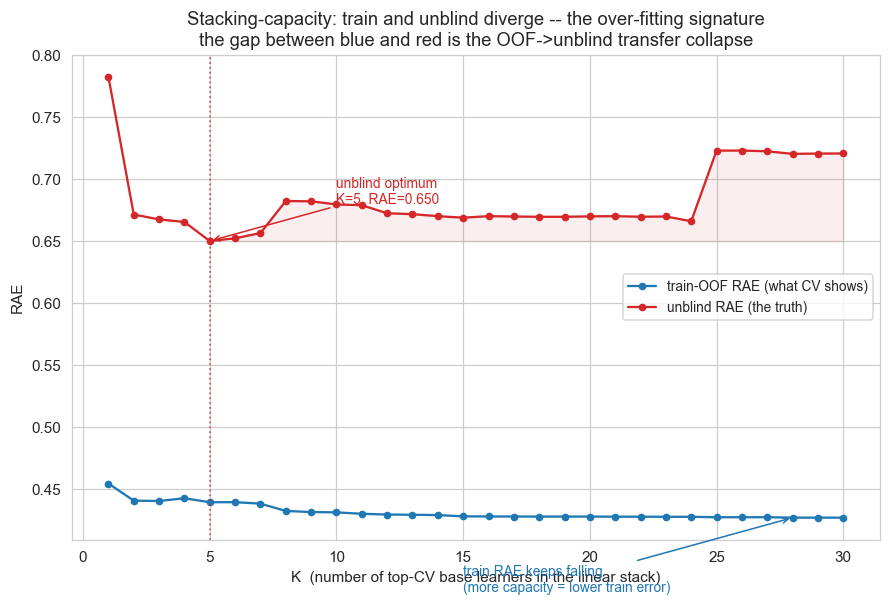

In [8]:
BASE_FAMS = ["gbdt","gnn","structure3D","external_aug","aux_signal",
             "foundation_emb","knn_analogy","mmp_fragment","domain_adapt","other"]
# genuine base learners with real (non-leaky) CV signal
mb = m[(m.family.isin(BASE_FAMS)) & (m.train_oof_rae>=0.45) & (m.train_oof_rae<=0.80)]
ranked = [COL[n] for n in mb.sort_values("train_oof_rae").name if n in COL]
print(f"candidate base learners: {len(ranked)}")

Ks = list(range(1,31))
tr_curve, un_curve = [], []
for K in Ks:
    cols = ranked[:K]
    A   = np.column_stack([np.ones(len(ty)), oof[:,cols]])   # OLS stack, fit on train-OOF
    w,_,_,_ = np.linalg.lstsq(A, ty, rcond=None)
    tr_curve.append(rae(ty, A @ w))
    Au  = np.column_stack([np.ones(len(y)), P[:,cols]])      # apply SAME weights to unblind
    un_curve.append(rae(y, Au @ w))
tr_curve=np.array(tr_curve); un_curve=np.array(un_curve)
K_best_un = Ks[int(un_curve.argmin())]; BEST_UN = float(un_curve.min())
K_best_tr = Ks[int(tr_curve.argmin())]; BEST_TR = float(tr_curve.min())
print(f"best unblind RAE at K={K_best_un}: {BEST_UN:.4f}")
print(f"best train  RAE at K={K_best_tr}: {BEST_TR:.4f}  (train keeps improving with K)")

fig, ax = plt.subplots(figsize=(8.2,5.6))
ax.plot(Ks, tr_curve, "-o", color="#1f77b4", ms=4, label="train-OOF RAE (what CV shows)")
ax.plot(Ks, un_curve, "-o", color="#d62728", ms=4, label="unblind RAE (the truth)")
ax.axvline(K_best_un, color="#d62728", ls=":", lw=1.2, alpha=.7)
ax.annotate(f"unblind optimum\nK={K_best_un}, RAE={BEST_UN:.3f}",
            xy=(K_best_un, BEST_UN), xytext=(K_best_un+5, BEST_UN+.03),
            fontsize=9, color="#d62728",
            arrowprops=dict(arrowstyle="->", color="#d62728"))
ax.annotate("train RAE keeps falling\n(more capacity = lower train error)",
            xy=(28, tr_curve[-1]), xytext=(15, tr_curve[-1]-.06),
            fontsize=9, color="#1f77b4",
            arrowprops=dict(arrowstyle="->", color="#1f77b4"))
ax.fill_between(Ks, un_curve, BEST_UN, where=(np.array(Ks)>K_best_un),
                color="#d62728", alpha=.08)
ax.set_xlabel("K  (number of top-CV base learners in the linear stack)")
ax.set_ylabel("RAE")
ax.set_title("Stacking-capacity: train and unblind diverge -- the over-fitting signature\n"
             "the gap between blue and red is the OOF->unblind transfer collapse")
ax.legend(fontsize=9, loc="center right"); plt.tight_layout(); plt.show()

**What this teaches.** The blue curve (train-OOF) is monotone-ish downward: adding base
learners always lets the stack reduce in-sample error. The red curve (unblind) bottoms out
at **K~5** and then climbs -- every learner added past that point is fitting OOF noise that
does not exist on truth. A practitioner reading only the blue curve would happily stack 30
models; the red curve says the right answer was ~5. **This is exactly how our grand-stacks
(which blended dozens of components) ended up at 0.83 unblind.**

A subtle corollary: convex (non-negative, sum-to-one) blends look "safer" because they
can zero-out components, but they still *choose which components to weight using OOF noise*
-- the same disease with a milder cosmetic. The robust lesson is **few, decorrelated
components, weights validated out-of-distribution.**

## 4. Scaffold-CV optimism

Maybe plain OOF was the problem and a proper **scaffold-CV** would have been honest?
We test that directly. For three solid base learners we re-aggregate each model's existing
train OOF predictions into scaffold-disjoint folds (using `scaffold_kfold_indices` on the
4,139 train scaffolds) and average the per-fold RAE -- an honest scaffold-CV estimate.
We then compare to the model's actual unblind RAE. Even honest scaffold-CV under-states
the unblind error by a systematic **+0.05 to +0.13**.

           model  scaffold_cv  scaffold_cv_sd  unblind   gap
   oof_lgbm_base        0.565           0.038    0.690 0.126
oof_chemprop_aux        0.571           0.039    0.622 0.050
    oof_catboost        0.564           0.036    0.679 0.115

mean scaffold-CV -> unblind gap: +0.097


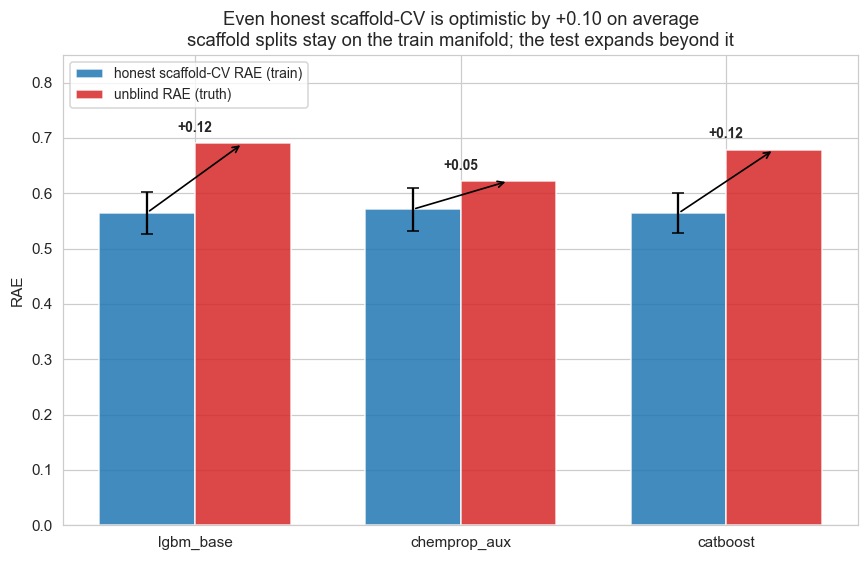

In [9]:
from pxr.eval import scaffold_kfold_indices
splits = scaffold_kfold_indices(scaf["scaffold"].tolist(), n_splits=5)
base3 = ["oof_lgbm_base","oof_chemprop_aux","oof_catboost"]
rows=[]
for nm in base3:
    ci = COL[nm]
    fold_raes = [rae(ty[v], oof[v,ci]) for _,v in splits]
    scv = float(np.mean(fold_raes)); scv_sd = float(np.std(fold_raes))
    un  = float(meta[meta.name==nm].iloc[0].te_unblind_rae)
    rows.append(dict(model=nm, scaffold_cv=round(scv,3), scaffold_cv_sd=round(scv_sd,3),
                     unblind=round(un,3), gap=round(un-scv,3)))
gap_df = pd.DataFrame(rows)
SCAF_GAP = float(gap_df.gap.mean())
print(gap_df.to_string(index=False))
print(f"\nmean scaffold-CV -> unblind gap: +{SCAF_GAP:.3f}")

fig, ax = plt.subplots(figsize=(8.0,5.2))
xpos = np.arange(len(base3)); w=.36
b1=ax.bar(xpos-w/2, gap_df.scaffold_cv, w, color="#1f77b4", alpha=.85,
          yerr=gap_df.scaffold_cv_sd, capsize=4, label="honest scaffold-CV RAE (train)")
b2=ax.bar(xpos+w/2, gap_df.unblind,    w, color="#d62728", alpha=.85,
          label="unblind RAE (truth)")
for i,(s,u) in enumerate(zip(gap_df.scaffold_cv, gap_df.unblind)):
    ax.annotate("", xy=(i+w/2, u), xytext=(i-w/2, s),
                arrowprops=dict(arrowstyle="->", color="black", lw=1.1))
    ax.text(i, max(s,u)+.02, f"+{u-s:.2f}", ha="center", fontsize=9, weight="bold")
ax.set_xticks(xpos); ax.set_xticklabels([n.replace("oof_","") for n in base3])
ax.set_ylabel("RAE"); ax.set_ylim(0, 0.85)
ax.set_title(f"Even honest scaffold-CV is optimistic by +{SCAF_GAP:.2f} on average\n"
             "scaffold splits stay on the train manifold; the test expands beyond it")
ax.legend(fontsize=9, loc="upper left"); plt.tight_layout(); plt.show()

**What this teaches.** Scaffold-CV is *better* than random CV (it at least holds scaffolds
out), but it is still computed entirely within the train chemical space. The unblind test
is an analog expansion that reaches into scaffolds with **zero** train support, so even a
scaffold-disjoint fold over-represents the easy, well-covered regions. The result is a
stubborn, positive offset: subtract roughly **+0.10** from optimism whenever you only have
a train-side number.

## 5. Root cause: where the two invisible failure modes live

Two failure modes drive the unblind error, and **both are invisible to any train-only
metric.** Below we connect them to the chemistry of the unblind set so the mechanism is
concrete: (a) universal **variance compression** -- the consensus prediction spans only
~62% of the truth range; (b) a **novel-scaffold inactive tail** -- truly dead compounds on
scaffolds with zero train support get pulled up to ~4.6 because they look ~50% similar to
known actives.

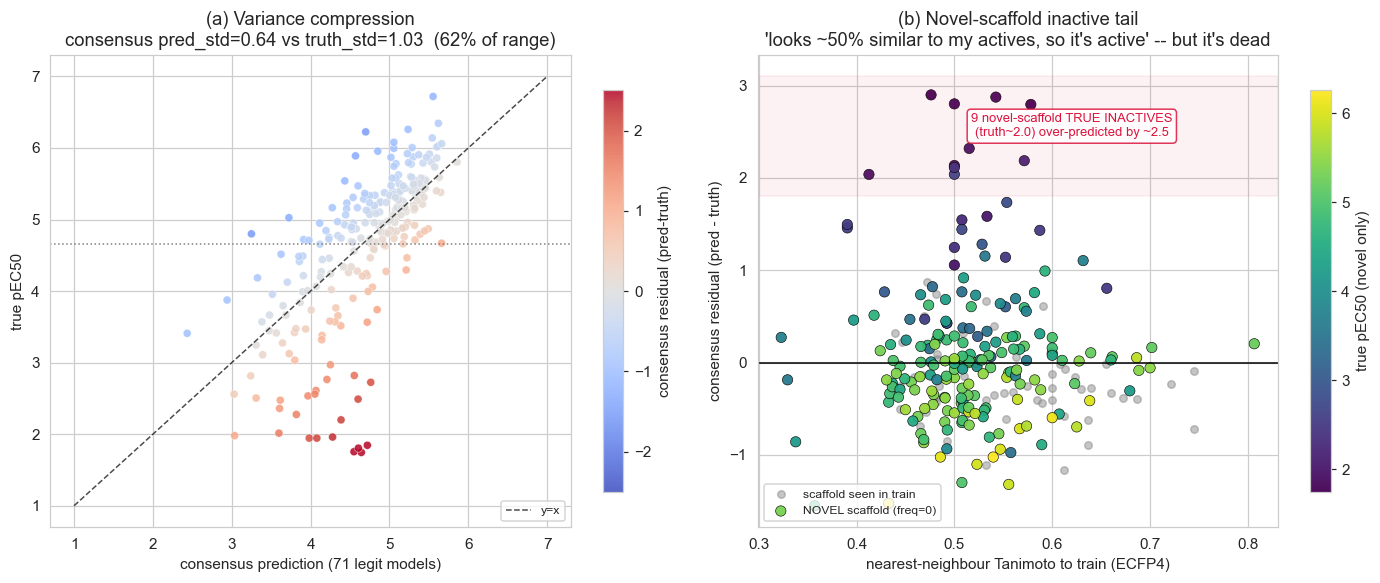

In [10]:
fig, axes = plt.subplots(1,2, figsize=(13,5.4))

# (a) variance compression: consensus pred vs truth, colored by residual
ax=axes[0]
sc=ax.scatter(cu.consensus_pred, cu.truth, c=cu.consensus_resid, cmap="coolwarm",
              vmin=-2.5, vmax=2.5, s=28, alpha=.85, edgecolor="white", linewidth=.3)
ax.plot([1,7],[1,7],"k--",lw=1,alpha=.7,label="y=x")
ax.axhline(cu.truth.mean(), color="0.5", ls=":", lw=1)
ax.set_xlabel("consensus prediction (71 legit models)")
ax.set_ylabel("true pEC50")
ax.set_title(f"(a) Variance compression\nconsensus pred_std={cu.consensus_pred.std():.2f} "
             f"vs truth_std={TRUTH_STD:.2f}  ({cu.consensus_pred.std()/TRUTH_STD*100:.0f}% of range)")
plt.colorbar(sc, ax=ax, label="consensus residual (pred-truth)", shrink=.85)
ax.legend(fontsize=8, loc="lower right")

# (b) novel-scaffold inactive tail: residual vs nn_sim_train, sized by truth, novel scaffolds flagged
ax=axes[1]
nov = cu.scaf_train_freq==0
ax.scatter(cu.loc[~nov,"nn_sim_train"], cu.loc[~nov,"consensus_resid"],
           s=24, alpha=.5, color="0.55", label="scaffold seen in train")
sc2=ax.scatter(cu.loc[nov,"nn_sim_train"], cu.loc[nov,"consensus_resid"],
               c=cu.loc[nov,"truth"], cmap="viridis", s=46, alpha=.95,
               edgecolor="black", linewidth=.4, label="NOVEL scaffold (freq=0)")
ax.axhline(0, color="black", lw=1)
# call out the worst inactive tail
worst = cu[nov & (cu.truth<2.5) & (cu.consensus_resid>1.8)]
ax.axhspan(1.8, cu.consensus_resid.max()+.2, xmin=0, xmax=1, color="crimson", alpha=.06)
ax.text(0.62, 2.45, f"{len(worst)} novel-scaffold TRUE INACTIVES\n"
        f"(truth~{worst.truth.mean():.1f}) over-predicted by ~{worst.consensus_resid.mean():.1f}",
        color="crimson", fontsize=8.5, ha="center",
        bbox=dict(boxstyle="round", fc="white", ec="crimson", alpha=.85))
ax.set_xlabel("nearest-neighbour Tanimoto to train (ECFP4)")
ax.set_ylabel("consensus residual (pred - truth)")
ax.set_title("(b) Novel-scaffold inactive tail\n'looks ~50% similar to my actives, so it's active' -- but it's dead")
plt.colorbar(sc2, ax=ax, label="true pEC50 (novel only)", shrink=.85)
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.show()

**What this teaches.** Panel (a): the consensus point cloud is flattened toward the mean --
high-truth actives are under-predicted, low-truth inactives are over-predicted (the red
points along the bottom). The models collectively span only ~62% of the truth's variance.
Panel (b): the worst residuals are concentrated in **novel-scaffold true inactives** at
nn_sim ~0.5 -- the model interprets moderate similarity to known actives as evidence of
activity, but these compounds are dead. Neither phenomenon can appear in a train-OOF metric:
train compounds *have* train neighbours by construction, and the train label distribution
*is* what the model compresses toward, so the compression is invisible from the inside.

### Are the 253 unblind even representative of the train-OOF world?

One more check that explains the whole collapse: the unblind compounds live materially
further from the train manifold than the train compounds do from each other. We compare the
distribution of nearest-neighbour-to-train similarity and the novel-scaffold fraction for
the unblind 253 versus the full 513 test set.

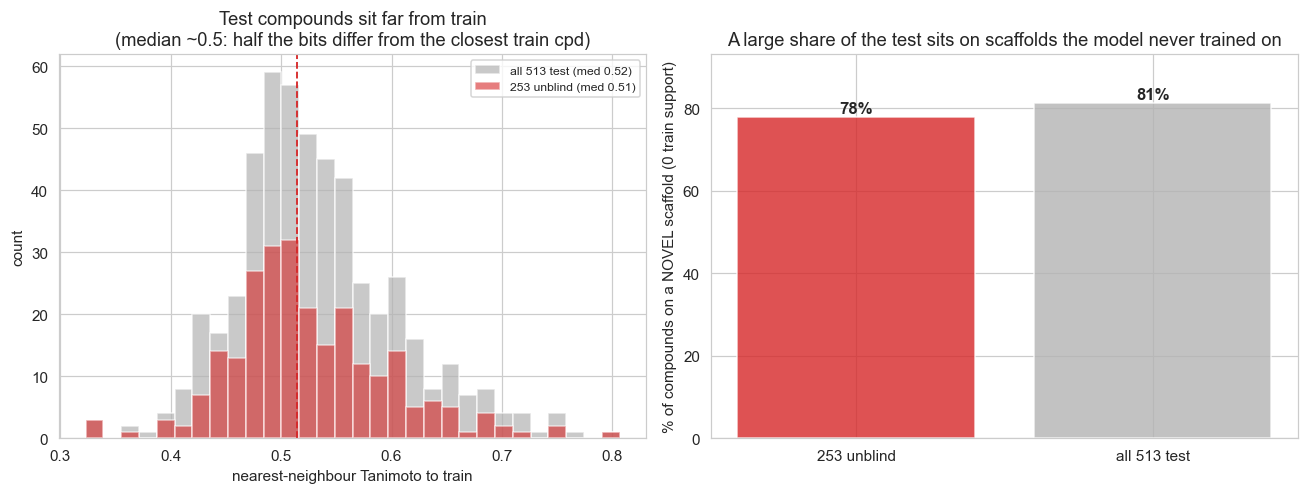

In [11]:
allt = pd.read_parquet(PM+"/pm_test_chem_all513.parquet")
fig, axes = plt.subplots(1,2, figsize=(12,4.6))
ax=axes[0]
ax.hist(allt.nn_sim_train, bins=30, color="0.7", alpha=.7, label=f"all 513 test (med {allt.nn_sim_train.median():.2f})")
ax.hist(cu.nn_sim_train,   bins=30, color="#d62728", alpha=.6, label=f"253 unblind (med {cu.nn_sim_train.median():.2f})")
ax.axvline(cu.nn_sim_train.median(), color="#d62728", ls="--", lw=1.2)
ax.set_xlabel("nearest-neighbour Tanimoto to train"); ax.set_ylabel("count")
ax.set_title("Test compounds sit far from train\n(median ~0.5: half the bits differ from the closest train cpd)")
ax.legend(fontsize=8)

ax=axes[1]
frac_unb = (cu.scaf_train_freq==0).mean()
frac_all = (allt.scaf_train_freq==0).mean()
bars=ax.bar(["253 unblind","all 513 test"], [frac_unb*100, frac_all*100],
            color=["#d62728","0.7"], alpha=.8)
for b,v in zip(bars,[frac_unb,frac_all]):
    ax.text(b.get_x()+b.get_width()/2, v*100+1, f"{v*100:.0f}%", ha="center", fontsize=11, weight="bold")
ax.set_ylabel("% of compounds on a NOVEL scaffold (0 train support)")
ax.set_ylim(0, max(frac_unb,frac_all)*100+12)
ax.set_title("A large share of the test sits on scaffolds the model never trained on")
plt.tight_layout(); plt.show()

**What this teaches.** Median nn-similarity to train is ~0.5 (roughly half the ECFP4 bits
differ from the closest training compound), and a large fraction of the test set is on
scaffolds with zero train support. The unblind 253 mirror the full 513, so this is not a
sampling fluke of the unblind subset -- it is the structural reality of the challenge.
Train-OOF metrics measure performance on the dense, well-covered core; the test grades us
on the sparse, novel rim.

## Summary scorecard and the Phase-2 rule

A single panel that captures the whole post-mortem: where each model selection strategy
*thought* it was (train-OOF RAE, light) versus where it actually landed (unblind RAE, dark).

                                   strategy       cv  unblind
overfit grand-stack\n(adaptive_delta_4tier) 0.162593 0.834091
                              LightGBM base 0.560014 0.690427
                             Chemprop (aux) 0.566544 0.621573
                      best single (pcs_iso) 0.560996 0.582473
         naive consensus\n(71 legit models)      NaN 0.648313


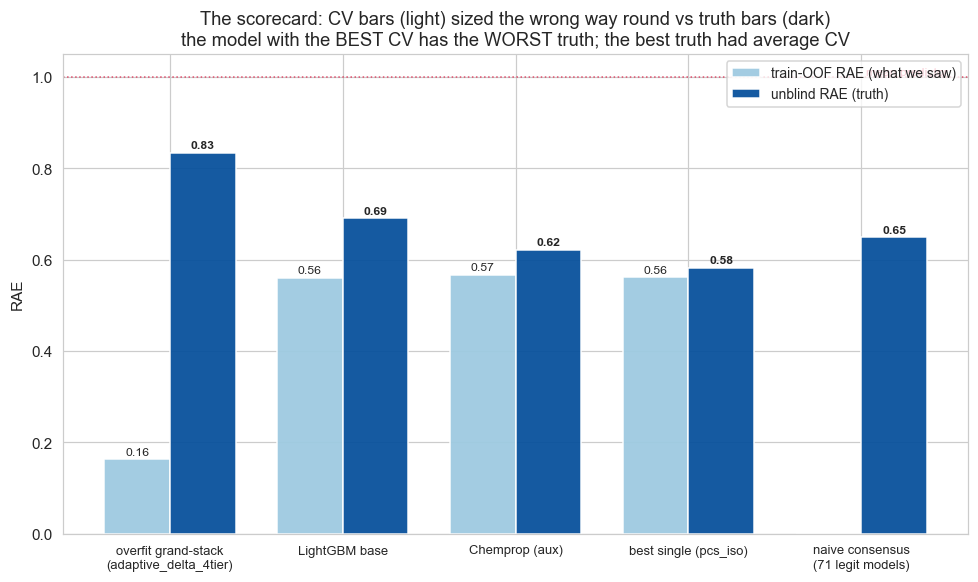

In [12]:
strategies = {
    "overfit grand-stack\n(adaptive_delta_4tier)": ("oof_adaptive_delta_4tier", None),
    "LightGBM base":                                ("oof_lgbm_base", None),
    "Chemprop (aux)":                               ("oof_chemprop_aux", None),
    "best single (pcs_iso)":                        ("oof_nb390_pcs_iso", None),
}
rows=[]
for label,(nm,_) in strategies.items():
    r=meta[meta.name==nm].iloc[0]
    rows.append((label, r.train_oof_rae, r.te_unblind_rae))
# naive consensus of legit models
legit=[n for n in m[m.te_unblind_rae<0.72].name if n in COL]
ci_legit=[COL[n] for n in legit]
cons_un=rae(y, P[:,ci_legit].mean(1))
# fitted OLS stack at unblind-optimal K (from the experiment) -- still a train-only choice
cols=ranked[:K_best_un]; A=np.column_stack([np.ones(len(ty)),oof[:,cols]])
w,_,_,_=np.linalg.lstsq(A,ty,rcond=None); cons_oof=rae(ty,A@w)
rows.append((f"naive consensus\n(71 legit models)", np.nan, cons_un))
sc_df=pd.DataFrame(rows, columns=["strategy","cv","unblind"])
print(sc_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9.0,5.4))
xpos=np.arange(len(sc_df)); w2=.38
ax.bar(xpos-w2/2, sc_df.cv.fillna(0), w2, color="#9ecae1",
       label="train-OOF RAE (what we saw)", alpha=.95)
ax.bar(xpos+w2/2, sc_df.unblind, w2, color="#08519c",
       label="unblind RAE (truth)", alpha=.95)
for i,r in sc_df.iterrows():
    if not np.isnan(r.cv): ax.text(i-w2/2, r.cv+.01, f"{r.cv:.2f}", ha="center", fontsize=8)
    ax.text(i+w2/2, r.unblind+.01, f"{r.unblind:.2f}", ha="center", fontsize=8, weight="bold")
ax.axhline(1.0, color="crimson", ls=":", lw=1, alpha=.7)
ax.text(len(sc_df)-.5, 1.005, "mean predictor", color="crimson", fontsize=8, ha="right")
ax.set_xticks(xpos); ax.set_xticklabels(sc_df.strategy, fontsize=8.5)
ax.set_ylabel("RAE"); ax.set_ylim(0,1.05)
ax.set_title("The scorecard: CV bars (light) sized the wrong way round vs truth bars (dark)\n"
             "the model with the BEST CV has the WORST truth; the best truth had average CV")
ax.legend(fontsize=9, loc="upper right"); plt.tight_layout(); plt.show()

### Phase-2 rule (the deliverable of this notebook)

1. **Never select on train-only metrics alone.** Train-OOF and even scaffold-CV are
   measured on the train manifold; the test is an analog expansion onto a partly-novel rim
   they cannot see. Empirically the optimism is **+0.05 to +0.13 RAE** -- budget a
   conservative **+0.10 shift** onto any train-only number before trusting it.
2. **Validate blend weights only on held-out, unblind-like data.** Now that 253 truths
   exist, fit and *cross-fit* every blend on those (or on a scaffold-novel hold-out
   designed to mimic them), not on the 4,139 train OOFs. The train-OOF stacking curve
   bottomed at K~5 on truth while continuing to "improve" on train forever.
3. **Prefer few, decorrelated components.** The stacking-capacity experiment shows unblind
   error rises past ~5 components. Convex blends only *look* safer -- they still pick weights
   from OOF noise. A handful of genuinely different model families beats a 30-way stack.
4. **Demand calibration that travels.** Reject any model whose predicted-vs-true slope or
   pred_std changes materially between train-OOF and a held-out set; that delta *is* the
   overfit. Add an explicit variance-decompression / abstention step for the novel-scaffold
   inactive tail, since no in-manifold metric will flag it.

In [13]:
# Key numbers returned to the orchestrator (printed for the record).
KEY = dict(
    corr_cv_unblind            = round(float(r_win),3),
    spearman_cv_unblind        = round(float(rho),3),
    bestcv_cohort_unblind_median = round(BESTCV_MED,3),
    blend_K_best_unblind       = int(K_best_un),
    blend_K_best_train         = int(K_best_tr),
    scaffoldcv_gap_estimate    = round(SCAF_GAP,3),
)
print(json.dumps(KEY, indent=2))

{
  "corr_cv_unblind": 0.474,
  "spearman_cv_unblind": -0.073,
  "bestcv_cohort_unblind_median": 0.772,
  "blend_K_best_unblind": 5,
  "blend_K_best_train": 30,
  "scaffoldcv_gap_estimate": 0.097
}
